In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

In [4]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [25]:
df_DA = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA = df_DA.dropna(subset=['salary_year_avg'])
df_DA = df_DA.explode('job_skills')


In [34]:
df_DA_group = df_DA.groupby('job_skills').agg(
    median_salary=('salary_year_avg', 'median'),
    skills_count = ('job_skills', 'count')
)

df_DA_top_pay = df_DA_group.sort_values(by='median_salary', ascending=False).head(10)
df_DA_in_demand = df_DA_group.sort_values(by='skills_count', ascending=False).head(10).sort_values(by='median_salary', ascending=False)


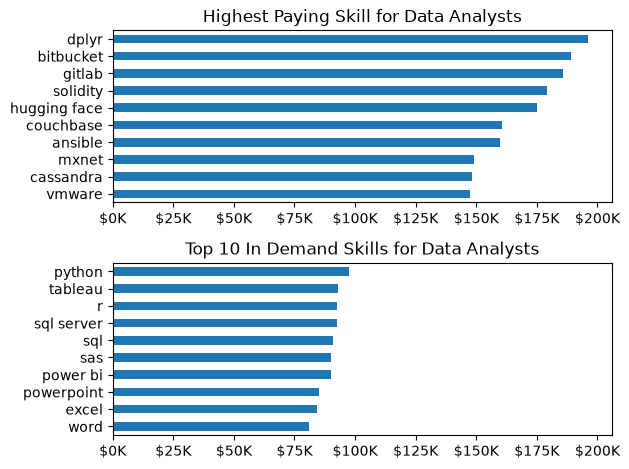

In [49]:
fig, ax = plt.subplots(2,1)

df_DA_top_pay.plot(kind='barh', y='median_salary', ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Highest Paying Skill for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].legend().set_visible(False)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

df_DA_in_demand.plot(kind='barh', y='median_salary', ax=ax[1])
ax[1].invert_yaxis()
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 In Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('')
ax[1].legend().set_visible(False)
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

plt.tight_layout()
plt.show()

